In [5]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [3]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [19]:
df['country'] = df['country'].fillna('Unknown')
df = df.dropna(subset=['date_added', 'rating', 'duration'])

In [20]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

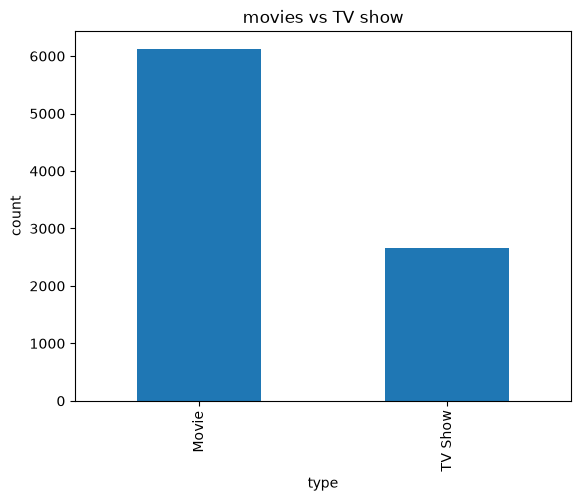

In [6]:
df['type'].value_counts().plot(kind='bar')
plt.title('movies vs TV show')
plt.ylabel('count')
plt.show()

In [12]:
df[df['country'] != 'Unknown']['country'].value_counts().head(10)

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

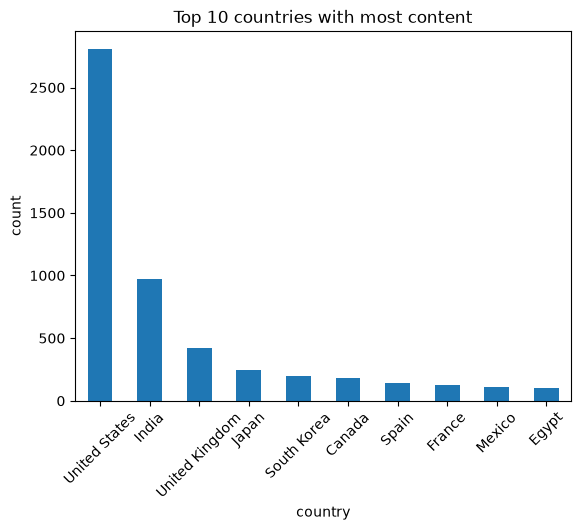

In [11]:
df[df['country'] != 'Unknown']['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 countries with most content')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

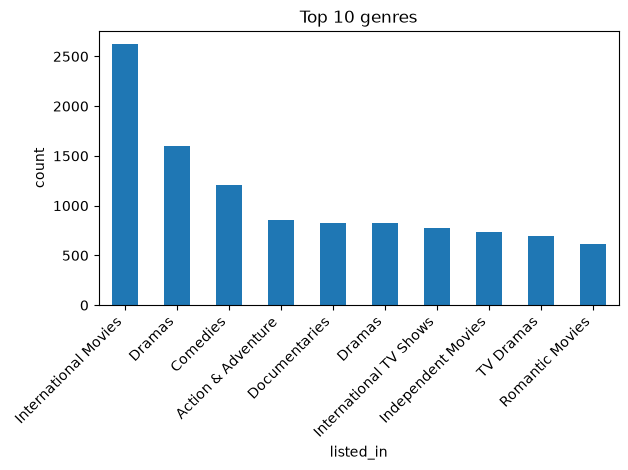

In [17]:
df["listed_in"].str.split(',').explode().value_counts().head(10).plot(kind='bar')
plt.title('Top 10 genres')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

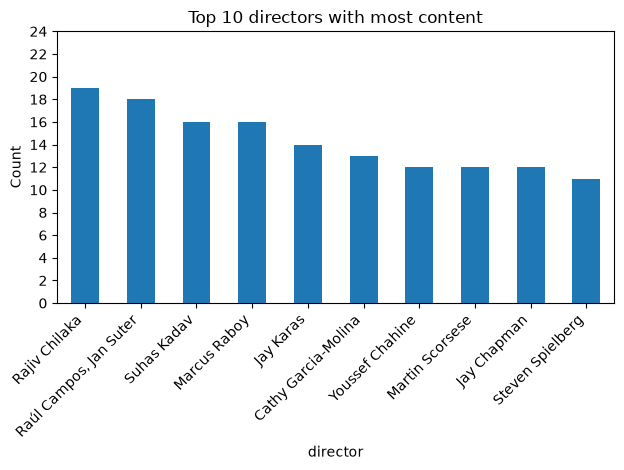

In [23]:
df[df['director'].notnull()]['director'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 directors with most content')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.yticks(range(0, 26, 2))
plt.tight_layout()
plt.show()

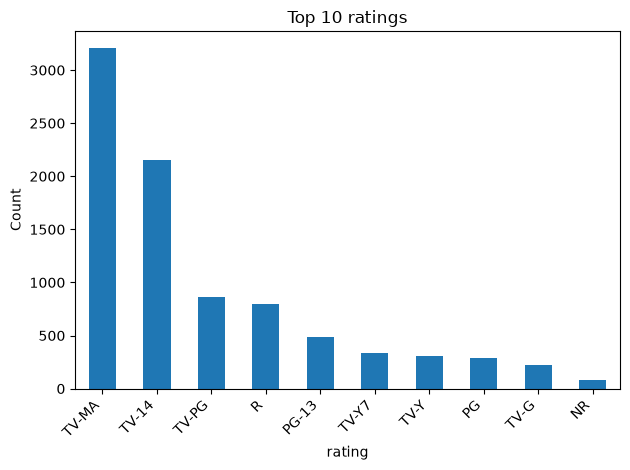

In [24]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 ratings') 
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

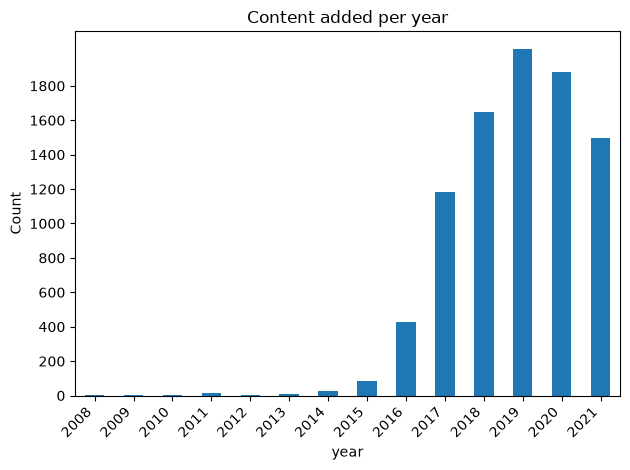

In [29]:
df['year_added'] = pd.to_datetime(df['date_added'].str.strip()).dt.year

df['year_added'].value_counts().sort_index().plot(kind='bar')
plt.title('Content added per year')
plt.ylabel('Count')
plt.yticks(range(0, 2000, 200))
plt.xlabel('year')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()